### IMPORT LIBRARY

In [1]:
import re

import numpy as np
import pandas as pd

### IMPORT DATASET

In [2]:
Dataset = pd.read_csv('Dataset/MBTI Dataset.csv')

DATASET EXPLORATION

In [3]:
print("Dataset : ", Dataset.shape)
print(Dataset.shape[0], "Entries with", Dataset.shape[1], "Columns")

Dataset.head()

Dataset :  (8675, 2)
8675 Entries with 2 Columns


,Type,Posts
0,INFJ,'http://www.youtube.com/watch?v=qsXHcwe3krw|||...
1,ENTP,'I'm finding the lack of me in these posts ver...
2,INTP,'Good one _____ https://www.youtube.com/wat...
3,INTJ,"'Dear INTP, I enjoyed our conversation the o..."
4,ENTJ,'You're fired.|||That's another silly misconce...


In [4]:
DF = pd.DataFrame()

DF['Count'] = Dataset.count()
DF['Unique'] = Dataset.nunique()
DF['Null Count'] = Dataset.isna().sum()

DF

,Count,Unique,Null Count
Type,8675,16,0
Posts,8675,8675,0


---
### DATASET TRANSFORMATION

In [5]:
Dataset['IE'] = Dataset['Type'].str.contains('E').astype(int)
Dataset['NS'] = Dataset['Type'].str.contains('S').astype(int)
Dataset['FT'] = Dataset['Type'].str.contains('T').astype(int)
Dataset['PJ'] = Dataset['Type'].str.contains('J').astype(int)

DATASET CLEANING FUNCTION

In [6]:
regexes = [
    #punctuation
    r'(?:(\w+)\'s)',
    
    r'(?:\s(\w+)\.+\s)',
    r'(?:\s(\w+),+\s)',
    r'(?:\s(\w+)\?+\s)',
    r'(?:\s(\w+)!+\s)',
    
    r'(?:\'+(\w+)\'+)',
    r'(?:"+(\w+)"+)',
    r'(?:\[+(\w+)\]+)',
    r'(?:{+(\w+)}+)',
    r'(?:\(+(\w+))',
    r'(?:(\w+)\)+)',

    #words containing numbers & special characters & punctuation
    r'(?:(?:(?:[a-zA-Z])*(?:[0-9!"#$%&\'()*+,\-./:;<=>?@\[\\\]^_`{|}~])+(?:[a-zA-Z])*)+)',
    
    #pure words
    r'([a-zA-Z]+)',
]

regex = re.compile(r'(?:'+'|'.join(regexes)+')', re.VERBOSE | re.IGNORECASE)

In [7]:
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords


def DataCleaning(Texts):
    Stopwords = stopwords.words('english')
    Lemmatizer = WordNetLemmatizer()

    Result = []
    for i, Text in enumerate(Texts):
        print('{0}/{1}'.format(i + 1, len(Texts)))

        NoUseRegex = re.compile(r'[^a-zA-Z]')
        Tokens = regex.findall(Text)

        List =[]
        for token in Tokens:
            token = np.array(token)
            token = np.unique(token[token != ''])

            if len(token) > 0:
                token = token[0].lower()
            else:
                continue
            
            if re.search(NoUseRegex, token) == None and token not in Stopwords:
                token = Lemmatizer.lemmatize(token)
                List.append(token)
        
        List = ' '.join(List)

        if len(List) >= 0:
            Result.append(List)
    
    return np.array(Result)


Dataset['Post'] = DataCleaning(Dataset['Posts'])

1/8675
2/8675
3/8675
4/8675
5/8675
6/8675
7/8675
8/8675
9/8675
10/8675
11/8675
12/8675
13/8675
14/8675
15/8675
16/8675
17/8675
18/8675
19/8675
20/8675
21/8675
22/8675
23/8675
24/8675
25/8675
26/8675
27/8675
28/8675
29/8675
30/8675
31/8675
32/8675
33/8675
34/8675
35/8675
36/8675
37/8675
38/8675
39/8675
40/8675
41/8675
42/8675
43/8675
44/8675
45/8675
46/8675
47/8675
48/8675
49/8675
50/8675
51/8675
52/8675
53/8675
54/8675
55/8675
56/8675
57/8675
58/8675
59/8675
60/8675
61/8675
62/8675
63/8675
64/8675
65/8675
66/8675
67/8675
68/8675
69/8675
70/8675
71/8675
72/8675
73/8675
74/8675
75/8675
76/8675
77/8675
78/8675
79/8675
80/8675
81/8675
82/8675
83/8675
84/8675
85/8675
86/8675
87/8675
88/8675
89/8675
90/8675
91/8675
92/8675
93/8675
94/8675
95/8675
96/8675
97/8675
98/8675
99/8675
100/8675
101/8675
102/8675
103/8675
104/8675
105/8675
106/8675
107/8675
108/8675
109/8675
110/8675
111/8675
112/8675
113/8675
114/8675
115/8675
116/8675
117/8675
118/8675
119/8675
120/8675
121/8675
122/8675
123/8675
1

TRAIN TEST SPLIT

In [8]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split


Count = CountVectorizer(max_features=20000)
In = Count.fit_transform(Dataset['Posts'])

IETrainIN, IETestIN, IETrainOUT, IETestOUT = train_test_split(In, Dataset['IE'])
NSTrainIN, NSTestIN, NSTrainOUT, NSTestOUT = train_test_split(In, Dataset['NS'])
FTTrainIN, FTTestIN, FTTrainOUT, FTTestOUT = train_test_split(In, Dataset['FT'])
PJTrainIN, PJTestIN, PJTrainOUT, PJTestOUT = train_test_split(In, Dataset['PJ'])


TrainIN = [IETrainIN, NSTrainIN, FTTrainIN, PJTrainIN]
TrainOUT = [IETrainOUT, NSTrainOUT, FTTrainOUT, PJTrainOUT]

TestIN = [IETestIN, NSTestIN, FTTestIN, PJTestIN]
TestOUT = [IETestOUT, NSTestOUT, FTTestOUT, PJTestOUT]

---
### MACHINE LEARNING MODEL

MODEL CREATION

In [9]:
from sklearn.naive_bayes import MultinomialNB


AI_Model = {
    "IE Model" : MultinomialNB(),
    "NS Model" : MultinomialNB(),
    "FT Model" : MultinomialNB(),
    "PJ Model" : MultinomialNB()
}

MODEL TRAINING

In [10]:
for i, Model in enumerate(AI_Model.keys()):
    AI_Model[Model].fit(TrainIN[i], TrainOUT[i])

MODEL EVALUATION

For IE Model :
	Accuracy Score   : 80.13 %
	Precision Score  : 81.91000000000001 %
	Recall Score     : 80.13 %

	Classification Report :
               precision    recall  f1-score   support

           0       0.90      0.84      0.87      1677
           1       0.55      0.67      0.61       492

    accuracy                           0.80      2169
   macro avg       0.72      0.76      0.74      2169
weighted avg       0.82      0.80      0.81      2169



For NS Model :
	Accuracy Score   : 83.96000000000001 %
	Precision Score  : 84.91 %
	Recall Score     : 83.96000000000001 %

	Classification Report :
               precision    recall  f1-score   support

           0       0.92      0.89      0.91      1859
           1       0.45      0.51      0.48       310

    accuracy                           0.84      2169
   macro avg       0.68      0.70      0.69      2169
weighted avg       0.85      0.84      0.84      2169



For FT Model :
	Accuracy Score   : 79.94 %
	Precision 

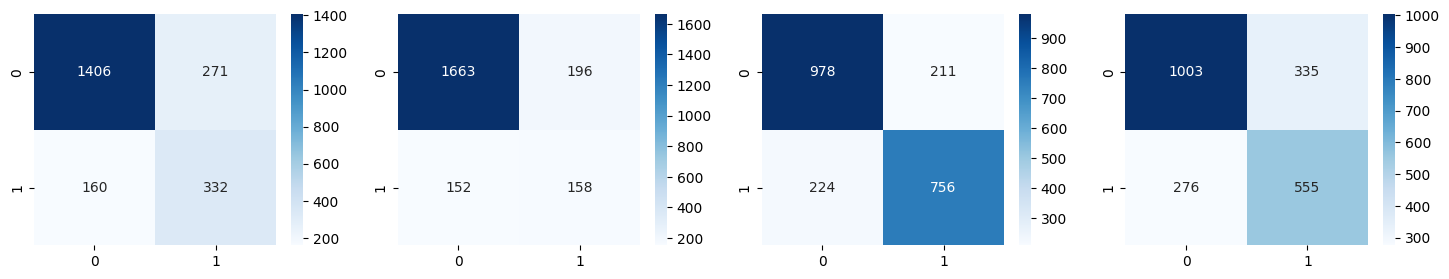

In [11]:
import seaborn as sns
import matplotlib.pyplot as plot
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, classification_report


for i, (Name, Model) in enumerate(AI_Model.items()):
    Pred = Model.predict(TestIN[i])

    print(f'For {Name} :')
    print('\tAccuracy Score   :', round(accuracy_score(TestOUT[i], Pred), 4)*100, "%")
    print('\tPrecision Score  :', round(precision_score(TestOUT[i], Pred, average='weighted', zero_division=1), 4)*100, "%")
    print('\tRecall Score     :', round(recall_score(TestOUT[i], Pred, average='weighted', zero_division=1), 4)*100, "%")

    print('\n\tClassification Report :\n', classification_report(TestOUT[i], Pred))
    print('\n')


figure, axes = plot.subplots(1,4, figsize=(18, 3))

for i, Model in enumerate(AI_Model.values()):
    Pred = Model.predict(TestIN[i])
    sns.heatmap(confusion_matrix(TestOUT[i], Pred), annot=True, fmt='d', cmap='Blues', ax=axes[i])

plot.show()

---
### GRAPHICAL INTERFACE

In [ ]:
Personality = [
    ["Mediator [ INFP ]",     "Mediators are Deeply Compassionate individuals, Driven by a Strong Sense of Empathy and the Desire to Speak Their Truth. They're on a Lifelong Quest for a Meaningful Purpose, Seeking to Understand the World around them while Advocating for Authenticity and Personal Growth. With their Idealistic Nature, they are often Found Supporting Causes close to their Hearts."],
    ["Advocate [ INFJ ]",     "Advocates are Passionate about Standing up for what’s Right. With an Innate Ability to Connect with Others on a Deep Level, they often find themselves on a Personal Mission to Make a Positive Impact. They Balance their Deep Sense of Morality with a Strong Vision for a Better World, and they are often Seen as Guides, Helping Others Find their Path."],
    ["Logician [ INTP ]",     "Logicians Thrive on Intellectual Challenges and are Fascinated by the Mysteries of the World. They are Natural Problem-Solvers, Driven by a Relentless Curiosity and a Deep Desire to Understand how Things Work. They Love Diving into Theoretical Concepts and Exploring Abstract Ideas, Constantly Seeking New Knowledge to Satisfy their Intellectual Hunger."],
    ["Architect [ INTJ ]",    "Architects are Strategic Thinkers, Always Looking for Innovative Solutions to Life’s Challenges. With a Thirst for Knowledge and an Analytical Mind, they Approach the World like a Grand Chess Game, Carefully Planning their Moves. They are Visionary Leaders who are Always Striving to Improve Systems and Find Better Ways to Navigate through Life."],
    ["Adventurer [ ISFP ]",   "Adventurers are Free-Spirited and Passionate Individuals who Live for New Experiences. They are Deeply in Tune with the Present Moment, Valuing Authenticity and Creativity in Everything they Do. Whether they are Exploring Nature or Crafting Something Unique, Adventurers Approach Life with a Sense of Wonder and are Constantly Seeking to Live an Inspired, Fulfilling Existence."],
    ["Defender [ ISFJ ]",     "Defenders are Caring and Protective Individuals who Place a High Value on Tradition and Loyalty. They Find Fulfillment in Nurturing Others and Ensuring that their Loved Ones are Supported and Safe. With a Strong Sense of Duty, Defenders are often Seen as Reliable Pillars in their Communities, Always Willing to Lend a Helping Hand to those in Need."],
    ["Virtuoso [ ISTP ]",     "Virtuosos are Independent Thinkers who Thrive on Action and Adventure. They Love to Break the Rules and Find Creative Ways to Approach Challenges. With a Hands-On Approach to Problem-Solving, they are Natural Innovators, Capable of Adapting to any Situation and Finding Practical Solutions on the Fly. Their Adventurous Spirit often Leads them to Explore Uncharted Territories."],
    ["Logistician [ ISTJ ]",  "Logisticians are Known for their Reliability, Organization, and Strong Sense of Responsibility. They Value Structure and Tradition, and they are Meticulous about Doing Things the Right Way. With a Grounded and Logical Approach to Life, Logisticians are the Ones you can Always Count on to Get Things Done and Maintain Order in any Situation."],
    ["Campaigner [ ENFP ]",   "Campaigners are Vibrant, Optimistic Individuals who Bring Energy and Enthusiasm to Everything they Do. They are Deeply Curious and Love Exploring New Ideas, Constantly Seeking Joy and Meaning in Life. With a Natural Ability to Connect with Others, Campaigners Inspire those around them with their Passion, Creativity, and Drive to Make the World a Better Place."],
    ["Protagonist [ ENFJ ]",  "Protagonists are Empathetic and Charismatic Leaders, Always Striving to Bring out the Best in Others. With a Deep Commitment to Making a Positive Impact, they are Driven by a Strong Sense of Purpose and a Desire to Connect People with a Shared Vision. Protagonists are often Seen as Mentors and Guides, Helping Others Find their Way and Inspiring them to Pursue their Dreams."],
    ["Debater [ ENTP ]",      "Debaters are Energetic, Quick-Witted Individuals who Love Challenging the Status Quo. They Thrive on Debate and Intellectual Stimulation, Constantly Looking for Ways to Test Ideas and Push Boundaries. With a Knack for Seeing Multiple Perspectives, Debaters are Natural Innovators, Always Seeking to Break Free from Conventional Thinking and Achieve their Full Potential."],
    ["Commander [ ENTJ ]",    "Commanders are Ambitious and Decisive Leaders who Excel in Strategic Planning and Execution. With a Clear Vision of what they want to Achieve, they Take Charge and are Always Focused on Driving Progress. Their Determination and Strong Organizational Skills Help them Lead Teams and Projects with Authority, Always Striving to Reach New Heights of Success."],
    ["Entertainer [ ESFP ]",  "Entertainers are Lively, Spontaneous, and Full of Energy. They have a Natural Ability to Bring Joy to those around them and are Always in Tune with the Present Moment. Whether they’re Performing, Socializing, or Simply Having Fun, Entertainers are Known for their Infectious Enthusiasm and their Ability to Turn any Situation into an Exciting Adventure."],
    ["Consul [ ESFJ ]",       "Consuls are Caring and Sociable Individuals who Thrive on Creating Harmony and Helping Others. They have a Deep Understanding of the Needs of those around them and are Always Ready to Lend a Helping Hand. With their Strong Sense of Community and Tradition, Consuls Play a Central Role in Maintaining Balance and Fostering Strong Relationships in their Families and Social Circles."],
    ["Entrepreneur [ ESTP ]", "Entrepreneurs are Action-Oriented Individuals who Thrive on Excitement and New Challenges. They are Bold, Adventurous, and Always Ready to Take Risks in Pursuit of their Goals. With a Sharp Ability to Assess Situations Quickly, Entrepreneurs are Natural Problem-Solvers, Capable of Thinking on their Feet and Navigating through Life with Confidence and Enthusiasm."],
    ["Executive [ ESTJ ]",    "Executives are Practical, Efficient, and Highly Organized Individuals who Excel at Taking Charge of Situations. They Value Order, Structure, and Responsibility, and they are Dedicated to Achieving their Goals. With their Strong Work Ethic and Commitment to Tradition, Executives are the Ones who Ensure that Things Get Done Right, Leading Others with Authority and Precision."]
]

In [ ]:
import tkinter as TK


class GUI(TK.Frame):
    def __init__(self, parent):
        super().__init__(parent)
        self.configure(bg="#FAFAFA")

        self.Base = TK.Frame(self, bg="#FAFAFA")
        self.Base.pack(fill='both', expand=True, padx=10, pady=10)


        # Line Input
        Line_Input = TK.Frame(self.Base)
        Line_Input.pack(side=TK.TOP, fill=TK.X, padx=5)

        Label = TK.Label(Line_Input, bg="#FAFAFA", text="ENTER YOUR TEXT BELOW", font=("Helvetica", 10, "bold"), anchor='sw')
        Button = TK.Button(Line_Input, bg="#4CAF50", text="PREDICT", font=("Helvetica", 10, "bold"), width=20, bd=0, command=self.predict)
        Label.pack(side=TK.LEFT, expand=True, fill=TK.BOTH)
        Button.pack(side=TK.LEFT, expand=False, ipadx=3, ipady=2)

        # Line Entry
        Textbox = TK.Frame(self.Base, bg="#FFF", highlightthickness=1, highlightbackground="black")
        Textbox.pack(side=TK.TOP, fill=TK.X, padx=5, pady=5)

        self.Text = TK.Entry(Textbox, bg="#FFF", width=100, bd=0, font=("Helvetica", 10), justify='center')
        self.Text.pack(side=TK.TOP, fill=TK.X, padx=6, pady=5)


        # Information Container
        self.TextList = [["IE Model", "INTROVERT VS EXTROVERT"], ["NS Model", "INTUITION VS SENSING"], ["FT Model", "FEELING VS THINKING"], ["PJ Model", "PERCEIVING VS JUDGEMENT"]]
        
        self.UIList = [[], [], [], []]
        LineList = []

        for x, Text in enumerate(self.TextList):
            LineList.append(TK.Frame(self.Base, bg="#FAFAFA"))
            LineList[x].pack(side=TK.TOP, fill=TK.X)

            for i in range(4):
                if i == 0 :
                    self.UIList[x].append(TK.Label(LineList[x], bg="#FAFAFA", text=self.TextList[x][1], font=("Helvetica", 10, 'bold'), anchor='w'))
                    self.UIList[x][i].pack(side=TK.LEFT, expand=True, fill=TK.X, padx=5, pady=5, ipadx=2, ipady=2)
                else :
                    self.UIList[x].append(TK.Label(LineList[x], bg="#FAFAFA", width=8, font=("Helvetica", 10, 'bold'), anchor='w'))
                    self.UIList[x][i].pack(side=TK.LEFT, fill=TK.X, padx=5, pady=5, ipadx=4, ipady=4)


        # Line Result
        self.Trait = TK.Label(self.Base, bg="#FAFAFA", font=("Helvetica", 12, 'bold'))
        self.Trait.pack(side=TK.TOP, fill=TK.X, padx=5, pady=5)

        # Line Description
        self.Desc = TK.Label(self.Base, bg="#FAFAFA", font=("Helvetica", 10), wraplength=650)
        self.Desc.pack(side=TK.TOP, fill=TK.X, padx=5, pady=2)


    def predict(self):
        if self.Text.get() != "":
            Num = 0
            Result = Count.transform([self.Text.get()])
            Selection = [("I", "E", 8), ("N", "S", 4), ("F", "T", 2), ("P", "J", 1)]

            for i, Line in enumerate(self.UIList):
                Line[1]['text'] = str(AI_Model[self.TextList[i][0]].predict_proba(Result)[0][0])[:4]
                Line[2]['text'] = str(AI_Model[self.TextList[i][0]].predict_proba(Result)[0][1])[:4]

                if Line[1]['text'] > Line[2]['text']:
                    Line[3]['text'] = Selection[i][0]
                else:
                    Line[3]['text'] = Selection[i][1]
                    Num += Selection[i][2]
            
        self.Trait['text'] = Personality[Num][0]
        self.Desc['text'] = Personality[Num][1]

In [55]:
class Interface(TK.Tk):
    def __init__(self):
        super().__init__()

        self.Screen = None
        self.Switch(GUI)
    
    def Switch(self, FrameClass):
        NewFrame = FrameClass(self)

        if self.Screen is not None:
            self.Screen.destroy()
        
        self.Screen = NewFrame
        self.Screen.pack(fill='both', expand=True)

In [ ]:
App = Interface()
App.title("Personality Prediction AI")
App.resizable(width=False, height=True)

App.mainloop()